In [35]:
#installing required libraries
!pip install librosa soundfile numpy pandas scikit-learn matplotlib seaborn tqdm -q

print(" Libraries installed successfully!")

 Libraries installed successfully!


In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported!")

 All libraries imported!


In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [118]:
import os

#Creating the main project directory
base_dir = '/content/drive/MyDrive/Conure_Vocalization_Clustering'
os.makedirs(base_dir, exist_ok=True)
os.makedirs(f"{base_dir}/data", exist_ok=True)
os.makedirs(f"{base_dir}/output", exist_ok=True)
os.makedirs(f"{base_dir}/models", exist_ok=True)

print(" Project folders created successfully!")
print(" Your project location:", base_dir)
print("Folders inside:", os.listdir(base_dir))

 Project folders created successfully!
 Your project location: /content/drive/MyDrive/Conure_Vocalization_Clustering
Folders inside: ['data', 'output', 'models']


In [119]:
# Creating a folder for the audio files
audio_folder = f"{base_dir}/data"

print(" Put your conure audio files in this folder:")
print(audio_folder)
print("\nAfter uploading your files, run the next cell.")

 Put your conure audio files in this folder:
/content/drive/MyDrive/Conure_Vocalization_Clustering/data

After uploading your files, run the next cell.


In [120]:
# Checking for the files

import os

audio_folder = '/content/drive/MyDrive/Conure_Vocalization_Clustering/data'

files = [f for f in os.listdir(audio_folder) if f.endswith(('.wav', '.mp3'))]
files.sort()

print(f" Found {len(files)} audio files:")
for i, f in enumerate(files, 1):
    print(f"{i}. {f}")

 Found 27 audio files:
1. XC146862 - Green-cheeked Parakeet - Pyrrhura molinae flavoptera.mp3
2. XC146863 - Green-cheeked Parakeet - Pyrrhura molinae flavoptera.mp3
3. XC1587 - Green-cheeked Parakeet - Pyrrhura molinae.mp3
4. XC2202 - Green-cheeked Parakeet - Pyrrhura molinae.mp3
5. XC272864 - Green-cheeked Parakeet - Pyrrhura molinae.mp3
6. XC272865 - Green-cheeked Parakeet - Pyrrhura molinae.mp3
7. XC272866 - Green-cheeked Parakeet - Pyrrhura molinae.mp3
8. XC272867 - Green-cheeked Parakeet - Pyrrhura molinae.mp3
9. XC29124 - Green-cheeked Parakeet - Pyrrhura molinae.mp3
10. XC29125 - Green-cheeked Parakeet - Pyrrhura molinae.mp3
11. XC296330 - Green-cheeked Parakeet - Pyrrhura molinae.mp3
12. XC3373 - Green-cheeked Parakeet - Pyrrhura molinae.mp3
13. XC3391 - Green-cheeked Parakeet - Pyrrhura molinae.mp3
14. XC351132 - Green-cheeked Parakeet - Pyrrhura molinae restricta.mp3
15. XC351186 - Green-cheeked Parakeet - Pyrrhura molinae restricta.mp3
16. XC4372 - Green-cheeked Parakeet - P

In [121]:
# Feature extraction with segmentation

import numpy as np
from tqdm import tqdm

def extract_segmented_features(audio_path, sr=None, segment_sec=3.0):
    try:
        y, sr = librosa.load(audio_path, sr=sr)
        duration = len(y) / sr

        segment_samples = int(segment_sec * sr)
        features_list = []

        for i in range(0, len(y), segment_samples):
            end = min(i + segment_samples, len(y))
            segment = y[i:end]

            if len(segment) < segment_samples * 0.7:  # Skip very short ending segments
                continue

            # Extract rich features from this segment
            mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=20)
            centroid = librosa.feature.spectral_centroid(y=segment, sr=sr)
            contrast = librosa.feature.spectral_contrast(y=segment, sr=sr)
            chroma = librosa.feature.chroma_cqt(y=segment, sr=sr)

            features = {
                'file': os.path.basename(audio_path),
                'segment_id': i // segment_samples,
                'segment_start_sec': round(i / sr, 2),
                'mfcc_mean': np.mean(mfcc, axis=1).tolist(),
                'spectral_centroid': np.mean(centroid),
                'spectral_contrast': np.mean(contrast),
                'chroma_mean': np.mean(chroma, axis=1).tolist()
            }
            features_list.append(features)

        return features_list

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return []

# Extract features from all files using segments
print(" Extracting features from segments...\n")

all_segments = []
files = sorted([f for f in os.listdir(audio_folder) if f.endswith(('.wav', '.mp3'))])

for file in tqdm(files):
    path = os.path.join(audio_folder, file)
    segments = extract_segmented_features(path)
    all_segments.extend(segments)

df_segments = pd.DataFrame(all_segments)
print(f" Created {len(df_segments)} segments from {len(files)} files")
display(df_segments.head())

 Extracting features from segments...



100%|██████████| 27/27 [01:18<00:00,  2.89s/it]

 Created 254 segments from 27 files


,file,segment_id,segment_start_sec,mfcc_mean,spectral_centroid,spectral_contrast,chroma_mean
0,XC146862 - Green-cheeked Parakeet - Pyrrhura m...,0,0.0,"[-425.42864990234375, 18.232975006103516, -100...",4996.147664,16.537112,"[0.6610656380653381, 0.6460644006729126, 0.723..."
1,XC146862 - Green-cheeked Parakeet - Pyrrhura m...,1,3.0,"[-451.5631103515625, 29.60666275024414, -92.39...",4865.695523,16.110658,"[0.681432843208313, 0.6289894580841064, 0.6693..."
2,XC146862 - Green-cheeked Parakeet - Pyrrhura m...,2,6.0,"[-485.98675537109375, 45.94659423828125, -77.2...",5026.722355,15.168882,"[0.6818126440048218, 0.67872154712677, 0.74999..."
3,XC146862 - Green-cheeked Parakeet - Pyrrhura m...,3,9.0,"[-336.99835205078125, -8.338424682617188, -149...",4798.853618,19.371167,"[0.49999356269836426, 0.530731737613678, 0.495..."
4,XC146862 - Green-cheeked Parakeet - Pyrrhura m...,4,12.0,"[-409.3087463378906, 3.103044033050537, -96.26...",5269.630640,17.549665,"[0.6156488656997681, 0.6550248861312866, 0.718..."


In [122]:
# Preparing features for clustering

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Prepare the feature matrix from segments
mfcc_features = np.array(df_segments['mfcc_mean'].tolist())
centroid_features = df_segments['spectral_centroid'].values.reshape(-1, 1)
contrast_features = df_segments['spectral_contrast'].values.reshape(-1, 1)
chroma_features = np.array(df_segments['chroma_mean'].tolist())

# Combine all features
X = np.hstack([mfcc_features, centroid_features, contrast_features, chroma_features])

print(f"Feature matrix shape: {X.shape} (188 segments × number of features)")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(" Features prepared and scaled!")

Feature matrix shape: (254, 34) (188 segments × number of features)
 Features prepared and scaled!


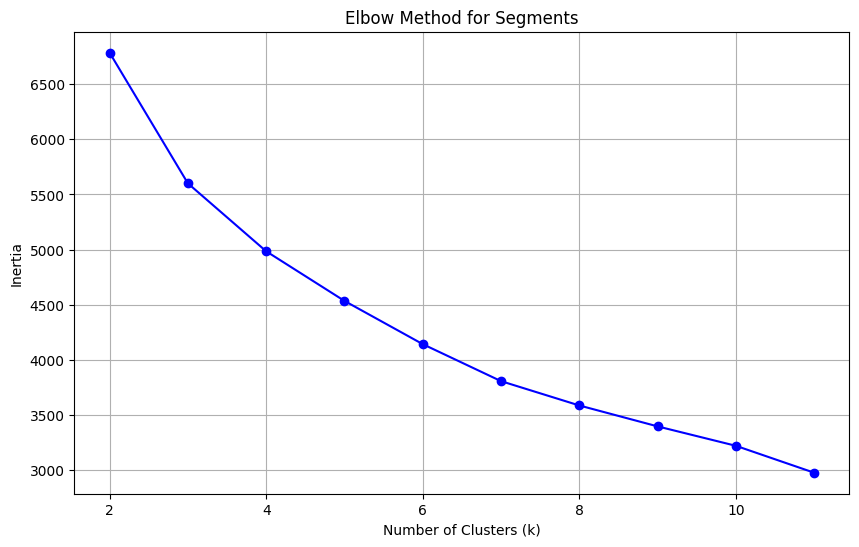

In [123]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertias = []
K = range(2, 12)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Segments')
plt.grid(True)
plt.show()

In [124]:
optimal_k = 4   # ← Good choice based on your elbow plot

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_segments['cluster'] = kmeans.fit_predict(X_scaled)

print(f" Clustering completed with {optimal_k} clusters!\n")

# Summary of clusters
print(" Number of segments per cluster:")
print(df_segments['cluster'].value_counts().sort_index())

# Show examples from each cluster
print("\nSample segments from each cluster:")
display(df_segments[['file', 'segment_id', 'segment_start_sec', 'cluster']].groupby('cluster').head(3))

 Clustering completed with 4 clusters!

 Number of segments per cluster:
cluster
0    82
1    29
2    94
3    49
Name: count, dtype: int64

Sample segments from each cluster:


,file,segment_id,segment_start_sec,cluster
0,XC146862 - Green-cheeked Parakeet - Pyrrhura m...,0,0.0,2
1,XC146862 - Green-cheeked Parakeet - Pyrrhura m...,1,3.0,2
2,XC146862 - Green-cheeked Parakeet - Pyrrhura m...,2,6.0,2
3,XC146862 - Green-cheeked Parakeet - Pyrrhura m...,3,9.0,3
6,XC146862 - Green-cheeked Parakeet - Pyrrhura m...,6,18.0,0
14,XC1587 - Green-cheeked Parakeet - Pyrrhura mol...,0,0.0,0
15,XC1587 - Green-cheeked Parakeet - Pyrrhura mol...,1,3.0,0
48,XC272864 - Green-cheeked Parakeet - Pyrrhura m...,1,3.0,3
49,XC272864 - Green-cheeked Parakeet - Pyrrhura m...,2,6.0,3
210,XC864628 - Green-cheeked Parakeet - Pyrrhura m...,27,81.0,1


In [127]:
import IPython.display as ipd
import random

def play_segment(file_name, segment_id):
    row = df_segments[(df_segments['file'] == file_name) &
                      (df_segments['segment_id'] == segment_id)].iloc[0]
    audio_path = os.path.join(audio_folder, file_name)

    y, sr = librosa.load(audio_path, sr=None,
                        offset=row['segment_start_sec'],
                        duration=3.0)

    print(f"Cluster {row['cluster']} | {file_name} | Segment {segment_id} | {row['segment_start_sec']:.1f}s")
    return ipd.Audio(y, rate=sr)

print(" Listening to multiple samples from each cluster...\n")

for cluster_id in range(4):
    print(f"===== CLUSTER {cluster_id} =====")
    samples = df_segments[df_segments['cluster'] == cluster_id].sample(n=min(3, len(df_segments[df_segments['cluster'] == cluster_id])), random_state=42)

    for _, row in samples.iterrows():
        widget = play_segment(row['file'], row['segment_id'])
        display(widget)
        print("-" * 40)
    print("\n")

 Listening to multiple samples from each cluster...

===== CLUSTER 0 =====
Cluster 0 | XC2202 - Green-cheeked Parakeet - Pyrrhura molinae.mp3 | Segment 14 | 42.0s


----------------------------------------
Cluster 0 | XC146862 - Green-cheeked Parakeet - Pyrrhura molinae flavoptera.mp3 | Segment 6 | 18.0s


----------------------------------------
Cluster 0 | XC2202 - Green-cheeked Parakeet - Pyrrhura molinae.mp3 | Segment 6 | 18.0s


----------------------------------------


===== CLUSTER 1 =====
Cluster 1 | XC924066 - Green-cheeked Parakeet - Pyrrhura molinae.wav | Segment 25 | 75.0s


----------------------------------------
Cluster 1 | XC924066 - Green-cheeked Parakeet - Pyrrhura molinae.wav | Segment 14 | 42.0s


...

----------------------------------------
Cluster 2 | XC602758 - Green-cheeked Parakeet - Pyrrhura molinae.mp3 | Segment 1 | 3.0s


----------------------------------------


===== CLUSTER 3 =====
Cluster 3 | XC864628 - Green-cheeked Parakeet - Pyrrhura molinae.wav | Segment 1 | 3.0s


----------------------------------------
Cluster 3 | XC864628 - Green-cheeked Parakeet - Pyrrhura molinae.wav | Segment 35 | 105.0s


----------------------------------------
Cluster 3 | XC971367 - Green-cheeked Parakeet - Pyrrhura molinae.mp3 | Segment 0 | 0.0s


----------------------------------------




In [128]:
# Silhouette score

from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df_segments['cluster'])
print(f"Silhouette Score (k=5): {score:.4f}")

# Also compare across k values
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    s = silhouette_score(X_scaled, labels)
    print(f"k={k}: Silhouette = {s:.4f}")

Silhouette Score (k=5): 0.2323
k=2: Silhouette = 0.2228
k=3: Silhouette = 0.2247
k=4: Silhouette = 0.2323
k=5: Silhouette = 0.2441
k=6: Silhouette = 0.2595
k=7: Silhouette = 0.2698
k=8: Silhouette = 0.2732
k=9: Silhouette = 0.2585


In [129]:
km8 = KMeans(n_clusters=8, random_state=42, n_init=10)
df_segments['cluster'] = km8.fit_predict(X_scaled)
print(df_segments['cluster'].value_counts().sort_index())

cluster
0    27
1    43
2    14
3    36
4    37
5    27
6    32
7    38
Name: count, dtype: int64


In [130]:
km6 = KMeans(n_clusters=6, random_state=42, n_init=10)
df_segments['cluster'] = km6.fit_predict(X_scaled)
print(df_segments['cluster'].value_counts().sort_index())

cluster
0    35
1    45
2    47
3    29
4    61
5    37
Name: count, dtype: int64


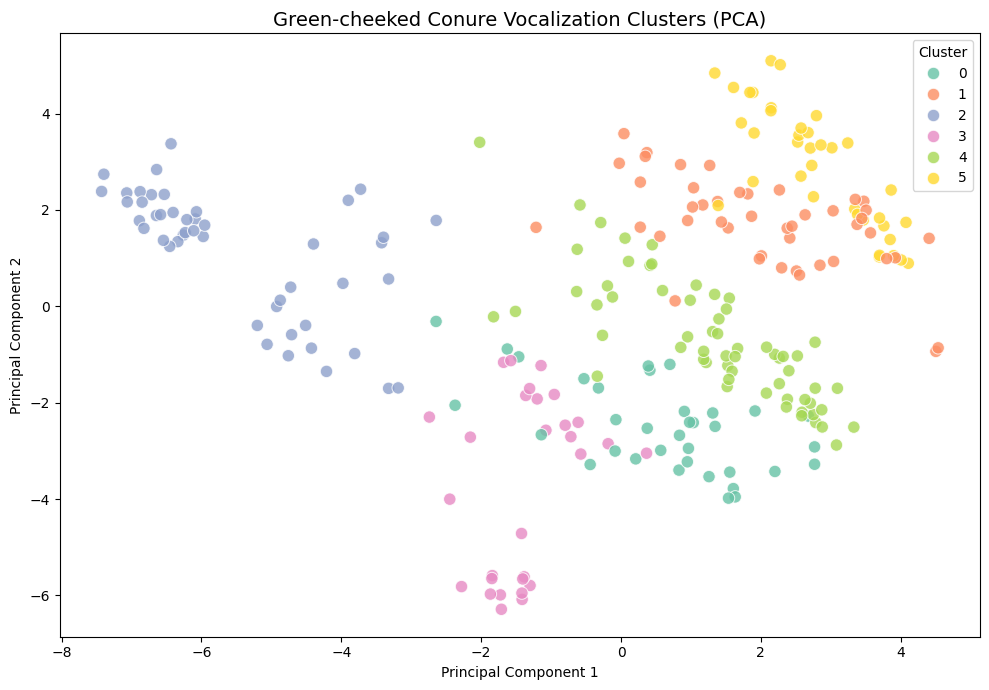

In [131]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Lock in k=6
km6 = KMeans(n_clusters=6, random_state=42, n_init=10)
df_segments['cluster'] = km6.fit_predict(X_scaled)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=df_segments['cluster'],
                palette='Set2', s=80, alpha=0.8)
plt.title('Green-cheeked Conure Vocalization Clusters (PCA)', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Conure_Vocalization_Clustering/output/pca_final.png', dpi=150)
plt.show()

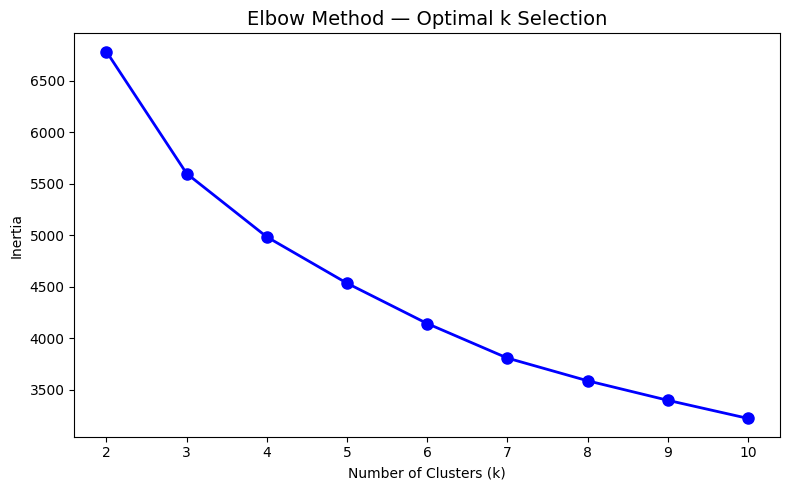

In [132]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.title('Elbow Method — Optimal k Selection', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Conure_Vocalization_Clustering/output/elbow_final.png', dpi=150)
plt.show()

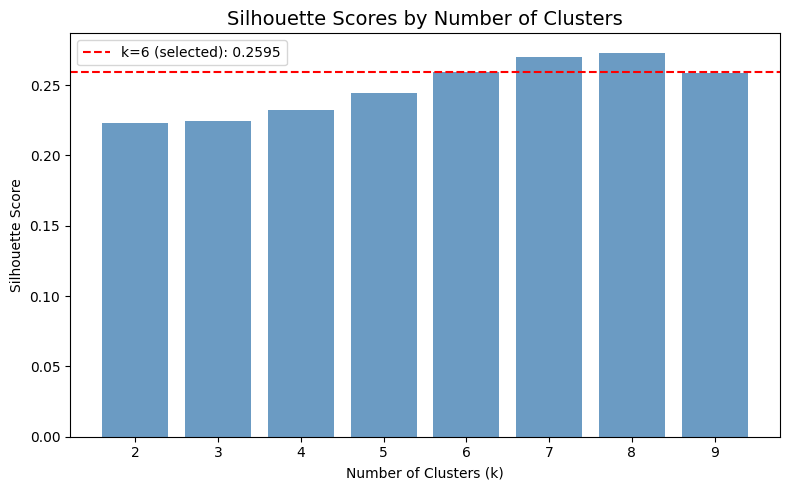

In [133]:
scores = {}
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)

plt.figure(figsize=(8, 5))
plt.bar(scores.keys(), scores.values(), color='steelblue', alpha=0.8)
plt.axhline(y=scores[6], color='red', linestyle='--', label=f'k=6 (selected): {scores[6]:.4f}')
plt.title('Silhouette Scores by Number of Clusters', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Conure_Vocalization_Clustering/output/silhouette_final.png', dpi=150)
plt.show()

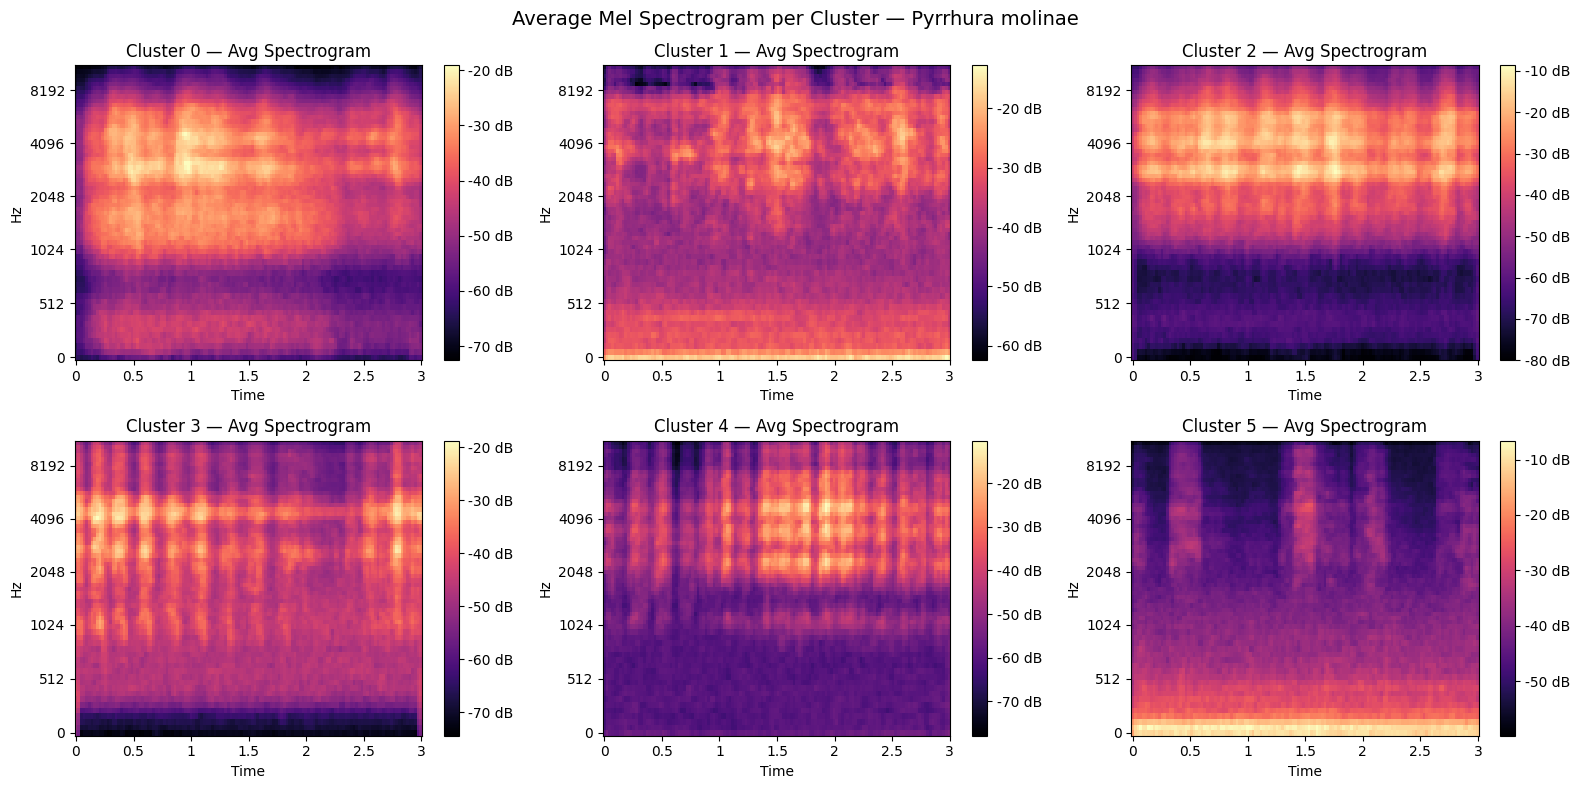

In [135]:
# AVERAGE SPECTOGRAM PER CLUSTER

import librosa.display

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for cluster_id in range(6):
    cluster_segs = df_segments[df_segments['cluster'] == cluster_id].head(5)
    mel_accumulator = []
    max_frames = 0 # Initialize max_frames for each cluster

    for _, row in cluster_segs.iterrows():
        filepath = os.path.join(base_dir, 'data', row['file'])
        y, sr = librosa.load(filepath,
                            offset=row['segment_start_sec'],
                            duration=3.0)
        if len(y) == 0: # Skip empty segments
            continue

        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_accumulator.append(mel_db)
        if mel_db.shape[1] > max_frames:
            max_frames = mel_db.shape[1]

    if not mel_accumulator: # Handle case where a cluster has no valid segments
        print(f"No valid segments found for Cluster {cluster_id}. Skipping.")
        axes[cluster_id].set_title(f'Cluster {cluster_id} — No Data')
        continue

    # Pad all spectrograms in the accumulator to max_frames
    padded_mels = []
    for mel_spec in mel_accumulator:
        # Pad with -80 dB, which typically represents silence in librosa's dB scale
        pad_width = max_frames - mel_spec.shape[1]
        if pad_width > 0:
            mel_spec = np.pad(mel_spec, ((0, 0), (0, pad_width)), mode='constant', constant_values=-80.0)
        padded_mels.append(mel_spec)

    avg_mel = np.mean(padded_mels, axis=0)
    img = librosa.display.specshow(avg_mel, sr=sr,
                                   x_axis='time',
                                   y_axis='mel',
                                   ax=axes[cluster_id])
    axes[cluster_id].set_title(f'Cluster {cluster_id} — Avg Spectrogram')
    fig.colorbar(img, ax=axes[cluster_id], format='%+2.0f dB')

plt.suptitle('Average Mel Spectrogram per Cluster — Pyrrhura molinae',
             fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Conure_Vocalization_Clustering/output/spectrograms_final.png', dpi=150)
plt.show()

In [136]:
summary = df_segments.groupby('cluster').agg(
    segment_count=('cluster', 'count'),
    avg_spectral_centroid=('spectral_centroid', 'mean'),
    avg_spectral_contrast=('spectral_contrast', 'mean')
).round(4)

print(summary)
summary.to_csv('/content/drive/MyDrive/Conure_Vocalization_Clustering/output/cluster_summary.csv')

         segment_count  avg_spectral_centroid  avg_spectral_contrast
cluster                                                             
0                   35              3645.9231                18.9271
1                   45              3963.0078                20.0382
2                   47              5587.7455                18.8641
3                   29              6277.9123                15.0988
4                   61              4639.6597                18.7823
5                   37              3886.2255                19.6580
